# Practical ADMET model training - when does it work?



<img src="./img/the_caco2.png" width="600">

*Dr Maria Castellanos*

## OMSF 2026 Demo

Hi all and welcome to the 2026 OpenADMET Demo! Here we will show an example of using our stack to do some training and finetuning on the [ExpansionRx dataset](https://huggingface.co/spaces/openadmet/OpenADMET-ExpansionRx-Challenge) that we recently ran a blind challenge on. This is an adaptation of some of the tutorials available at our [demos repo](https://demos.openadmet.org). Check it out for more detailed deep dives.

Our aim is to show in practice how one might use the OpenADMET stack to approach a **tangible set of program data**, some of the relevant pitfalls and how to finetune to optimise performance on your own programs. 




## The ExpansionRx dataset

Here we will use the ExpansionRx dataset as a test bed — the largest public ADMET dataset released to date from a real drug discovery program. It covers more than 7,500 compounds across 9 ADME assays collected over ~5 years for Expansion Therapeutics' programs in RNA-mediated and neurodegenerative diseases. This gives us a **realistic** program dataset to benchmark on across a full assay cascade.


<img src="img/expansion.png" width="600">


## Setting the stage

Consider this scenario: you have just started a new drug program and you want to use a model to predict certain ADMET endpoints to guide compound prioritisation. **There are several approaches you might take:**

* (1) Use **zero-shot models** — use pre-existing models already available in the public domain
* (2) Train your own model on **public data** — leverage publicly available data yourself
* (3) Train a model on **public data and your own program data** — combine public data with proprietary measurements

We will walk through each approach and evaluate performance against the ExpansionRx canonical test-train split.


## Zero-Shot models

Something you might try first is to use some **off-the shelf** pre-existing models. These models are in the public domain (often with webservers) and are the lowest overhead way to get an ADMET prediction. We will call this **zero-shot** prediction as these public models are trained on effectively unrelated data curated by the authors of these models. 

How likely is this to work? 

We will cover two popular webserver implementations 

* ADMET-AI, a ChemProp v1 GNN enhanced with RDKit descriptors trained on data from the Therapeutic Data Commons (TDC), and comes from a [web-based tool](https://admet.ai.greenstonebio.com/?ref=openadmet.ghost.io).

* ADMETLab 3.0 similarly is a ChemProp v1 model trained on 400,000 molecules curated from ChEMBL, PubChem and OCHEM. Its available at this web server [here](https://admetlab3.scbdd.com/?ref=openadmet.ghost.io).

## Starting with an easy endpoint: LogD

LogD is considered a relatively "learnable" endpoint due to its additive nature and strong correlation with computable quantities (cLogP and other descriptors). How does ADMETLab3 perform on the ExpansionRx LogD test set?

<img src="img/ADMETLab3_LogD.png" width="600">

Performance is poor for a learnable property, there is substantial scatter and the model shows clear systematic bias across the activity range. This is representative of what we typically see with zero-shot models on program data.


## Training on public data with Anvil

Much of the focus in our field has been on model architectures, but data quality and curation have an equally important role. It is worth asking whether a well-curated public dataset, trained with a rigorous pipeline, can outperform existing zero-shot tools.

With this in mind, OpenADMET has trained a series of public-data models available on our [HuggingFace](https://huggingface.co/openadmet). These are trained primarily on data curated from ChEMBL and serve as our **best-effort zero-shot models** built with the OpenADMET stack.

We use our [`Anvil` harness](https://github.com/OpenADMET/openadmet_models) to train models reproducibly for public use, combining it with our curated ChEMBL [data catalogs](https://github.com/OpenADMET/data-catalogs/issues). You can reproduce exactly what we have done very easily!

In [2]:
# read pre-curated data from our `data-catalogs` repo, more detail about reference code used to curate in our demos repo
# https://demos.openadmet.org

import intake 
cat = intake.open_catalog(
    "https://github.com/OpenADMET/data-catalogs/raw/refs/heads/main/catalogs/activities/ChEMBL_LogD/CATALOG_ChEMBL35_LogD.yaml"
)

In [3]:
list(cat.entries)

['LogD_aggregated', 'LogD_raw']

In [4]:
chembl_logd = cat["LogD_aggregated"].read()
chembl_logd.reset_index(drop=True).head()

,OPENADMET_CANONICAL_SMILES,OPENADMET_INCHIKEY,assay_id_count,standard_value_mean,standard_value_median,standard_value_std,pchembl_value_mean,pchembl_value_median,pchembl_value_std
0,CC(C)NCC(O)COC1=CC=CC2=CC=CC=C12,AQHHHDLHHXJYJD-UHFFFAOYSA-N,25,1.030800,1.220,0.452124,NaN,NaN,NaN
1,CCN(CC)CCCC(C)NC1=CC=NC2=CC(Cl)=CC=C12,WHTVZRBIWZFKQO-UHFFFAOYSA-N,19,0.404444,0.850,1.576232,NaN,NaN,NaN
2,CNCCCN1C2=CC=CC=C2CCC2=CC=CC=C21,HCYAFALTSJYZDH-UHFFFAOYSA-N,15,1.749267,1.100,2.382542,NaN,NaN,NaN
3,CN(C)CCCN1C2=CC=CC=C2CCC2=CC=CC=C21,BCGWQEUPMDMJNV-UHFFFAOYSA-N,15,1.948067,2.400,1.223295,NaN,NaN,NaN
4,COCCC1=CC=C(OCC(O)CNC(C)C)C=C1,IUBSYMUCCVWXPE-UHFFFAOYSA-N,14,-0.500714,-0.305,0.714363,NaN,NaN,NaN


Ok so using the data we have curated, lets train a model with Anvil! We use YAML config files to define simple training configurations, here training a CheMeleon foundation based GNN on LogD data (some additional curation from the above). Lets have a quick look at one of these YAML files. 

While this looks a bit complicated, these recipes are re-usable and highly configurable

We keep all of our canonical recipes here in a repo called [Optimus Prime](https://github.com/OpenADMET/optimus-prime)

In [11]:
import yaml
with open("./logd_inputs/logd_single_task_simple.yaml", 'r') as f:
    data = yaml.safe_load(f)
data

{'data': {'anvil_dir': 'file:///home/ec2-user/permeability_models/multitask/all_endpoints_model',
  'cat_entry': None,
  'dropna': False,
  'input_col': 'OPENADMET_CANONICAL_SMILES',
  'resource': '../../ChEMBL35_Caco2_permeability_multitask_atob_btoa_logD_mppb_final.parquet',
  'target_cols': ['logD',
   'caco2_atob_LogPapp',
   'caco2_btoa_LogPapp',
   'mppb_LogUnbound',
   'hppb_LogUnbound'],
  'test_resource': None,
  'train_resource': None,
  'type': 'intake',
  'val_resource': None},
 'metadata': {'authors': 'Maria A. Castellanos',
  'biotargets': ['Caco-2'],
  'build_number': 0,
  'description': 'basic regression using a ChemProp multitask task model',
  'driver': 'pytorch',
  'email': 'maria.castellanos@omsf.io',
  'name': 'chemprop_pchembl',
  'tag': 'chemprop',
  'tags': ['openadmet', 'example', 'chemprop'],
  'version': 'v1'},
 'procedure': {'ensemble': None,
  'feat': {'params': {'batch_size': 128,
    'n_jobs': 4,
    'normalize_targets': True},
   'type': 'ChemPropFeaturi

The sharp eyed among you will see that we cover the typical configureable decisions you would make when training a machine learning model. 

* Input data
* Splitting algorithm and ratios
* Molecular representation
* Model and hyperparameters
* Evaluation and CV

We can read this into a workflow (or construct in code directly)

In [12]:
from openadmet.models.anvil.specification import AnvilSpecification
spec = AnvilSpecification.from_recipe("./logd_inputs/anvil_logd.yaml")
spec

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

We can do run this  directly with the `openadmet-models` CLI (including the workflow construction step)

In [ ]:
!openadmet anvil --recipe-path logd_inputs/anvil_logd.yaml --output-dir logd_training

In [ ]:
!openadmet predict \
    --input-path data/exprx_test.csv \
    --input-col OPENADMET_CANONICAL_SMILES \
    --model-dir logd \
    --output-csv exprx_chembl_logd_predictions.csv \
    --accelerator cpu


Our actual **production** model that we released on [HuggingFace](https://huggingface.co/openadmet) uses **multitasking** in a set of related endpoints (often called task-affinity grouping) for slightly better performance. The performance of this model is shown below. Full instructions for using these models are provided on HuggingFace.

<img src="img/OADMET_LogD.png" width="600">

This is better than ADMET-AI model above, showing that execution is important, but still leaves a lot on the table relative to what you can do with training on actual data from the program! .

In [12]:
# BONUS, use the model we have on HuggingFace via Docker 

# git clone https://huggingface.co/permeability-logd-ppb-chemeleon-baseline/ && cd permeability-logd-ppb-chemeleon-baseline
# git lfs install && git lfs pull

# docker run -it --user=root --rm  \
#    -v ./permeability-logd-ppb-chemeleon-baseline:/home/mambauser/model:rw \
#    --runtime=nvidia \
#    --gpus \
#    all ghcr.io/openadmet/openadmet-models:main

# INSIDE the container run an example 
# ./run_model_inference.sh



## Zero-shot performance across all endpoints

We have evaluated zero-shot model performance across all endpoints where predictions are available from the public tools.

The plot below shows performance on the ExpansionRx test set for each endpoint and model. For context, we overlay results from the **ExpansionRx blind challenge** — over **400 participants** trained models on the ExpansionRx training set and submitted predictions. We include the challenge winner (`pebble`) and an LGBM baseline (RDKit fingerprints + descriptors) trained on the training set.



Zooming in on LogD first, we compare zero-shot models directly against models trained on the ExpansionRx training set. `pebble` is the challenge winner; the LGBM baseline uses RDKit fingerprints and descriptors trained on the same program data.

<img src="img/pebble_LogD.png" width="600">

Pebble's model is much much better than our "better executed" public data models (they also have a consortium and their own proprietary data), but it gets worse. Even a simple LGBM baseline trained on program data handily outperforms most zero-shot models. The full picture across all nine endpoints is below.

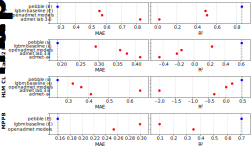

In [13]:
from IPython.display import SVG
SVG(filename='./img/anova_zero_shot.svg')

**Key things to note:**

- Zero-shot models consistently underperform models trained on program data
- The LGBM baseline trained on program data beats all zero-shot models across nearly every endpoint, despite much more intensive training and a much larger number of parameters.

## Zero-shot models are not sufficient for program-level prediction

The results are clear: zero-shot models do not generalise well to program data. While our ChEMBL-trained implementation shows some improvement over other public-data implementations, the core finding holds — **data is the key to good performance**. No amount of architectural sophistication compensates for the distributional mismatch between generic training data and a specific drug discovery program.

Let me just repeat that, **algorithm complexity cannot rescue a lack of data**. I don't think people acknowledge this uncomfortable truth enough. While there is some dependence on how your program relates to existing assayed chemical space, for most ADMET endpoints the sparsity of data makes this a moot point. 

This is key to our philosophy at OpenADMET, we as a community need to collect much more data and apply the rigorous techniques of drug discovery to anti-targets. 

## Where we are going 

We aim 

# Fine-tuning to your program

The analysis above establishes the baseline: to get useful predictions, in most cases you need to incorporate program data. The question then becomes *how* to do this efficiently.

OpenADMET supports fine-tuning a pre-trained public-data model on your own measurements — combining the broad chemical knowledge encoded in a large ChEMBL-trained model with the specificity of your program's chemical series. This is typically more efficient than training from scratch.

In the steps below we will:
1. Load the ExpansionRx training set
2. Fine-tune our public-data LogD model on this program data using `anvil`
3. Evaluate the fine-tuned model on the held-out test set and compare against the zero-shot baseline
